# AI for Disease Detection (Tabular ML Challenge)

## Story
In 2060, a global health network deploys portable diagnostic sensors in remote regions. Each sensor collects biological signals and environmental factors.
Students must predict whether a patient has a rare disease.


## Dataset Features
- Age
- BodyTemp
- HeartRate
- OxygenLevel
- ImmuneMarkerA
- ImmuneMarkerB
- BloodSugar
- SleepHours
- StressLevel
- PollutionExposure
- GeneticRiskScore
- PhysicalActivity
- NutritionScore

Target: DiseaseStage
- 0 = Healthy
- 1 = Early Stage Disease
- 2 = Severe Disease

Evaluation: Macro F1 Score


## Difficulty Elements
- Handle missing data
- Detect feature correlations
- Avoid overfitting
- Compare models

Expected algorithms: Logistic Regression, Decision Tree, Random Forest, KNN


## IOAI 2026 Skills Focus
Contestants should understand core concepts and theoretical underpinnings and develop the practical skills to implement AI methods in code, including using library functions effectively and interpreting outputs.


## Importing Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, classification_report

%matplotlib inline
sns.set_style("whitegrid")


## Loading the Data

In [17]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")
sample = pd.read_csv("SampleSubmission.csv")

print(f"Train shape: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"Test shape:  {test.shape[0]:,} rows, {test.shape[1]} columns")
print(f"Sample submission shape: {sample.shape[0]:,} rows, {sample.shape[1]} columns")
train.head()


Train shape: 8,000 rows, 15 columns
Test shape:  2,000 rows, 14 columns
Sample submission shape: 2,000 rows, 2 columns


,PatientID,Age,BodyTemp,HeartRate,OxygenLevel,ImmuneMarkerA,ImmuneMarkerB,BloodSugar,SleepHours,StressLevel,PollutionExposure,GeneticRiskScore,PhysicalActivity,NutritionScore,DiseaseStage
0,P000001,47,NaN,121.0,98.0,43.8,NaN,83.6,NaN,4.48,68.7,45.1,6.37,53.2,1
1,P000002,34,36.34,60.1,97.1,82.2,54.8,113.0,5.67,6.91,40.3,59.3,9.01,69.2,0
2,P000003,35,NaN,75.2,95.9,79.7,67.9,78.6,8.32,NaN,52.2,19.8,10.00,75.2,0
3,P000004,27,37.34,91.1,98.8,55.2,73.6,104.5,5.91,8.53,33.4,78.2,7.11,55.8,1
4,P000005,50,36.39,NaN,96.8,62.2,57.9,NaN,8.90,2.19,68.5,21.5,9.36,61.8,0


## Missing Values

In [18]:
missing = train.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing


ImmuneMarkerB        455
BodyTemp             430
NutritionScore       429
BloodSugar           422
PollutionExposure    410
ImmuneMarkerA        407
OxygenLevel          406
StressLevel          406
GeneticRiskScore     404
SleepHours           400
HeartRate            393
PhysicalActivity     375
dtype: int64

## Target Balance and Correlations

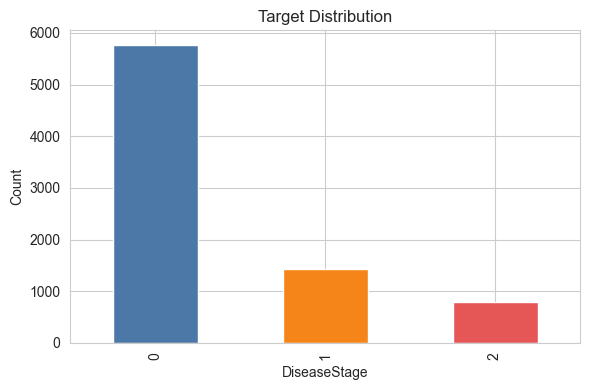

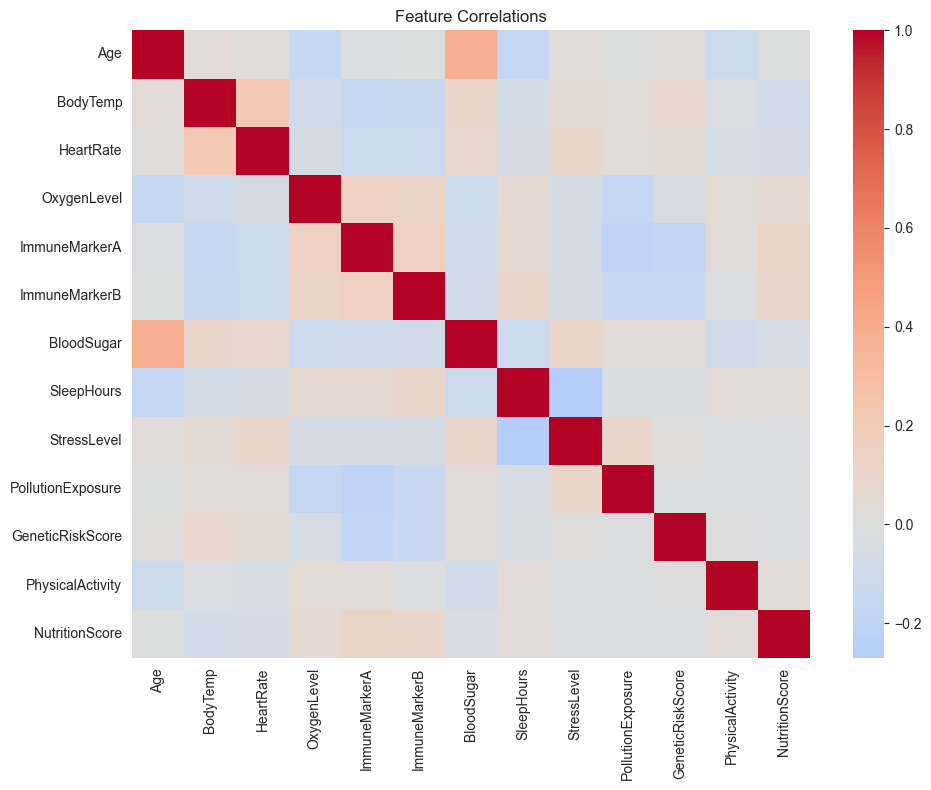

In [19]:
plt.figure(figsize=(6, 4))
train["DiseaseStage"].value_counts().sort_index().plot(kind="bar", color=["#4C78A8", "#F58518", "#E45756"])
plt.xlabel("DiseaseStage")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.tight_layout()
plt.show()

feature_cols = [
    "Age",
    "BodyTemp",
    "HeartRate",
    "OxygenLevel",
    "ImmuneMarkerA",
    "ImmuneMarkerB",
    "BloodSugar",
    "SleepHours",
    "StressLevel",
    "PollutionExposure",
    "GeneticRiskScore",
    "PhysicalActivity",
    "NutritionScore"
]

corr = train[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()


## Baseline Model (Logistic Regression)

In [20]:
X = train[feature_cols]
y = train["DiseaseStage"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)
model.fit(X_train_imp, y_train)

val_pred = model.predict(X_val_imp)
macro_f1 = f1_score(y_val, val_pred, average="macro")
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(y_val, val_pred))


Macro F1: 0.6232
              precision    recall  f1-score   support

           0       0.85      0.94      0.90      1728
           1       0.45      0.29      0.35       432
           2       0.66      0.59      0.62       240

    accuracy                           0.79      2400
   macro avg       0.65      0.61      0.62      2400
weighted avg       0.76      0.79      0.77      2400



## Generate Predictions and Submission

In [21]:
X_full = imputer.fit_transform(train[feature_cols])
model.fit(X_full, y)

X_test = imputer.transform(test[feature_cols])
test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "PatientID": test["PatientID"],
    "DiseaseStage": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()


,PatientID,DiseaseStage
0,P000001,0
1,P000002,0
2,P000003,0
3,P000004,0
4,P000005,0
